# SpatialProp LOO Evaluation

Mirrors `perturb_loo.ipynb` but uses the spatial-prop GNN instead of cellina.

**Experiment logic:**
- Hold out `holdout_celltype` cells from the CRC region during GNN training
- At inference, the GNN predicts those cells' expression from their *actual* CRC neighbors
- This CRC-neighbor prediction is the analog of cellina's spatial-context swap
- We measure how well the predicted CRC expression matches the real holdout cells using `compute_cf_logfc`

**Metrics (same as perturb_loo.ipynb):**
- `ref_expr` = GNN prediction for holdout cells *in REF* (from REF neighbors)
- `pert_expr` = GNN prediction for holdout cells *in CRC* (from CRC neighbors) ← the "perturbation"
- `cf_expr`  = real expression for holdout cells in CRC ← ground truth

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import os
import sys
sys.path.append('src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import pearsonr

from spatial_gnn.api.perturbation_api import (
    train_perturbation_model,
    create_perturbation_input_matrix,
    predict_perturbation_effects
)
from spatial_gnn.utils.plot_utils import (
    plot_loss_curves,
    plot_celltype_performance,
    plot_celltypes_in_section,
    plot_propagation_results_for_gene_set
)

from perturb_utils import load_crc_slide, split_indices, compute_cf_logfc

plt.rcParams['figure.dpi'] = 100

/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN5torch8autograd12VariableInfoC1ERKN2at6TensorE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred whi

In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id         = 232
labels_key       = 'coarse_type'
domains_key      = 'typ'
holdout_celltype = 'T_cell'   # change to 'Fibroblast', 'Myeloid', etc.
top_n            = 100        # genes for logFC metric evaluation
exp_name         = f'crc_loo_{holdout_celltype}'
out_dir          = f'./output/{exp_name}'

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'
top_n_perturb    = 50

## 1. Data Loading & Column Mapping

spatial-prop requires `obs["celltype"]`, `obs["mouse_id"]`, and optionally `obs["region"]`.

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)

adata.obs['celltype'] = adata.obs[labels_key]
adata.obs['mouse_id'] = str(slide_id)
adata.obs['region']   = adata.obs[domains_key]

print(adata)
print(f"\nCell types: {sorted(adata.obs['celltype'].unique())}")
print(f"Regions:    {sorted(adata.obs['region'].unique())}")

AnnData object with n_obs × n_vars = 111989 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [4]:
adata.X.max()

np.float64(721.0)

> **Caveat — coordinate units**: `obsm['spatial']` contains CosMx global pixel coordinates
> (~0.12 µm/px). spatial-prop's Delaunay graph pruning uses a radius cutoff hardcoded at
> 200 in `spatial_dataset.py`. If that unit is µm, 200 µm ÷ 0.12 µm/px ≈ 1667 px — meaning
> the cutoff of 200 would include only cells within ~24 µm, which may be too tight.
> Check whether `train_perturbation_model` accepts a `radius_cutoff` kwarg and set it
> accordingly (e.g. `"radius_cutoff": 1667`).

## 2. Holdout Split → adata_train / adata_test

In [5]:
train_idx, val_idx, test_idx = split_indices(
    adata, holdout_celltype=holdout_celltype,
    labels_key=labels_key, domains_key=domains_key,
)
# adata.obs['is_holdout'] is now True for holdout_celltype cells in any CRC region

print(f"train: {len(train_idx):,}  val: {len(val_idx):,}  holdout (CRC): {len(test_idx):,}")
print(f"Held-out cells: {adata.obs['is_holdout'].sum()} {holdout_celltype} in CRC region")

adata_train = adata[~adata.obs['is_holdout']].copy()   # holdout CRC cells excluded
adata_test  = adata.copy()                              # full slide for inference

os.makedirs(out_dir, exist_ok=True)
train_path = f'{out_dir}/adata_train.h5ad'
test_path  = f'{out_dir}/adata_test.h5ad'
adata_train.write(train_path)
adata_test.write(test_path)

print(f"\nSaved: {train_path}")
print(f"Saved: {test_path}")

train: 98,277  val: 10,919  holdout (CRC): 2,793
Held-out cells: 2793 T_cell in CRC region

Saved: ./output/crc_loo_T_cell/adata_train.h5ad
Saved: ./output/crc_loo_T_cell/adata_test.h5ad


## 3. Train SpatialProp GNN

> **Caveat — in-sample test loss**: `train_ids == test_ids` (single slide). The test loss
> reported during training reflects in-sample fit, not generalisation to the holdout cells.
> Real validation happens in Section 4 below.

In [6]:
training_args = {
    'dataset':             f'crc_{slide_id}_{holdout_celltype}',
    'file_path':           train_path,
    'train_ids':           [str(slide_id)],
    'test_ids':            [str(slide_id)],   # same — in-sample only
    'exp_name':            exp_name,
    'k_hop':               2,
    'augment_hop':         2,
    'center_celltypes':    'all',
    'node_feature':        'expression',
    'inject_feature':      'none',
    'learning_rate':       1e-4,
    'loss':                'weightedl1',
    'epochs':              30,
    'normalize_total':     True,
    'num_cells_per_ct_id': 100,
    'predict_celltype':    False,
    'pool':                'center',
    'do_eval':             False,
    'device':              'cuda' if torch.cuda.is_available() else 'cpu',
    # Uncomment and set if train_perturbation_model accepts radius_cutoff:
    # 'radius_cutoff': 1667,   # ~200 µm at 0.12 µm/px
}

test_loader, gene_names, (model, model_config, trained_model_path) = \
    train_perturbation_model(**training_args)

print(f"\nModel saved to: {trained_model_path}")

Training new perturbation model from scratch...
Model will be saved to: ./output/crc_loo_T_cell/crc_232_T_cell_expression_2hop_2augment_expression_none/weightedl1_1en04
Training on device: cuda
Dataset already exists at:  ./data/gnn_datasets/crc_232_T_cell_expression_100per_2hop_2C0aug_200delaunay_expressionFeat_all_NoneInject_subset_232/test
Finished processing test dataset
Dataset already exists at:  ./data/gnn_datasets/crc_232_T_cell_expression_100per_2hop_2C0aug_200delaunay_expressionFeat_all_NoneInject_subset_232/train
Finished processing train dataset


100%|██████████| 28/28 [00:05<00:00,  4.95it/s]
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
100%|██████████| 28/28 [00:06<00:00,  4.62it/s]

Train samples: 13506
Test samples: 13506


Expression model initialized on cuda
Starting GNN training for 30 epochs...
 Epoch: 001, Train WL1: 10.1161, Test WL1: 10.1159, Test Spearman: 0.0024
 Epoch: 002, Train WL1: 10.0906, Test WL1: 10.0906, Test Spearman: 0.0040
 Epoch: 003, Train WL1: 10.0708, Test WL1: 10.0707, Test Spearman: 0.0067
 Epoch: 004, Train WL1: 10.0562, Test WL1: 10.0562, Test Spearman: 0.0110
 Epoch: 005, Train WL1: 10.0445, Test WL1: 10.0444, Test Spearman: 0.0168
 Epoch: 006, Train WL1: 10.0348, Test WL1: 10.0348, Test Spearman: 0.0234
 Epoch: 007, Train WL1: 10.0267, Test WL1: 10.0268, Test Spearman: 0.0302
 Epoch: 008, Train WL1: 10.0209, Test WL1: 10.0210, Test Spearman: 0.0353
 Epoch: 009, Train WL1: 10.0166, Test WL1: 10.0166, Test Spearman: 0.0395
 Epoch: 010, Train WL1: 10.0133, Test WL1: 10.0134, Test Spearman: 0.0421
 Epoch: 011, Train WL1: 10.0112, Test WL1: 10.0112, Test Spearman: 0.0439
 Epoch: 012, Train WL1: 10.0093, Test WL1: 10.0094, Test Spearman: 0.0455
 Epoch: 013, Train WL1: 10.0079, Tes

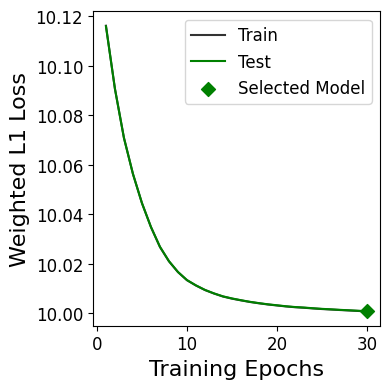

In [7]:
model_dir = os.path.dirname(trained_model_path)
plot_loss_curves(model_dir)

We can also plot performance of the model by cell type on the held-out mouse. Here we show correlation metrics for the masked center cell expression prediction task used during training.

In [8]:
# plot_celltype_performance(model_dir)

## 4. Inference on Full Slide

We use an identity perturbation (multiplier = 1.0) to satisfy the API.
The layer we care about is `predicted_unperturbed` — the GNN's prediction for
each cell from its actual neighbors.

In [9]:
# Identity perturbation: multiply first gene by 1.0 (no change)
identity_gene = adata_test.var_names[0]

In [10]:
import decoupler as dc
import scanpy as sc

pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col=domains_key,
    groups_col=labels_key,
    mode='sum',
    layer='counts',
)
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'

cell_types = [
    ct for ct in pdata.obs[labels_key].unique()
    if ((pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)).any()
    and ((pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)).any()
]

domain_logfc_df = pd.concat(
    [
        pd.Series(
            (
                pdata[(pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)].X
                - pdata[(pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata.var_names,
            name=ct,
        )
        for ct in cell_types
    ],
    axis=1,
).T

print(f"logFC matrix: {domain_logfc_df.shape}  (cell types × genes)")
domain_logfc_df.head()

logFC matrix: (7, 3000)  (cell types × genes)


,DES,SLC22A16,RNF186,TAFA3,GCSAM,RAB44,AWAT1,RTTN,MYO1F,PWWP2B,...,GPX8,ARMCX1,FBN2,ACYP2,RIPPLY1,PLAC8L1,LRCH2,ARHGAP6,DBNL,HAT1
Endothelial,-0.247933,0.030929,-0.132753,-0.074783,-0.336980,0.048579,-0.461400,-0.011090,-0.055737,-0.088087,...,-0.010124,-0.149009,-0.213081,-0.157315,-0.259867,-0.253751,-0.299324,-0.023891,-0.175992,0.199938
Epithelial,-0.033994,-0.457857,-0.222040,0.018591,-0.131009,-0.419756,-0.084441,-0.517717,-0.130881,-0.705174,...,-0.213566,-0.182887,-0.234025,-0.014209,-0.206537,-0.192728,-0.137533,0.023384,0.049195,0.113313
Fibroblast,-0.503774,-0.087190,-0.289097,-0.326220,-0.323539,-0.313739,-0.305978,-0.175104,-0.117715,-0.534841,...,-0.130831,-0.159516,-0.331626,-0.100066,-0.315532,-0.285171,-0.039989,-0.307851,-0.059330,-0.268954
Myeloid,-0.047840,-0.171747,-0.458499,0.336375,-0.701313,0.147773,0.168002,-0.076923,0.206223,-0.123577,...,-0.063122,-0.017510,-0.267740,0.063837,-0.058507,-0.525925,-0.069793,-0.284780,0.084352,0.174245
Plasma_cell,0.254469,0.104107,0.070434,0.043531,0.104575,0.145362,-0.042265,0.020217,0.298476,0.122146,...,0.090745,0.064771,0.177262,0.171509,0.001160,0.166247,0.101457,0.013942,-0.025968,0.145912


In [11]:
perturbation_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    top_genes = s.abs().nlargest(top_n_perturb).index.tolist()
    perturbation_dict[ct] = s[top_genes].to_dict()

In [12]:

perturbed_path = f'{out_dir}/adata_test_identity.h5ad'
create_perturbation_input_matrix(
    adata_test, perturbation_dict,
    save_path=perturbed_path,
    normalize_total=True,
)


Applying perturbations to 6766 cells of type 'Endothelial'
  - Gene 'COL1A1': multiplier = 1.5556655565177007
  - Gene 'SPARC': multiplier = 1.5541338559950826
  - Gene 'PYY': multiplier = -1.2860753924692698
  - Gene 'VIP': multiplier = 1.148277959549907
  - Gene 'IGHA1': multiplier = -1.1416732447067952
  - Gene 'MMADHC': multiplier = -1.128718091493468
  - Gene 'HSPA1B': multiplier = -1.0952132325804254
  - Gene 'MGP': multiplier = 1.0693963231555021
  - Gene 'COL4A1': multiplier = 1.0651837796590513
  - Gene 'COL1A2': multiplier = 1.005844312510297
  - Gene 'COL4A2': multiplier = 1.0014111696346792
  - Gene 'COL3A1': multiplier = 0.9386733014406414
  - Gene 'PRPH': multiplier = 0.9124111491551236
  - Gene 'IGFBP7': multiplier = 0.9077539989234493
  - Gene 'HSPA1A': multiplier = -0.8925366822570697
  - Gene 'BGN': multiplier = 0.8627437702301475
  - Gene 'LGALS1': multiplier = 0.8612066969586958
  - Gene 'TIMP1': multiplier = 0.8578266037779145
  - Gene 'CST1': multiplier = 0.833480

'./output/crc_loo_T_cell/adata_test_identity.h5ad'

In [13]:
adata_result = predict_perturbation_effects(
    perturbed_path,
    trained_model_path,
    exp_name,
    use_ids=[str(slide_id)],
)

print("Layers available:", list(adata_result.layers.keys()))
print("Result shape:", adata_result.shape)

Loaded model configuration:
  - input_dim: 3000
  - output_dim: 3000
  - inject_dim: 0
  - num_layers: 2
  - method: GIN
  - pool: center
Loaded pretrained model from: output/crc_loo_T_cell/crc_232_T_cell_expression_2hop_2augment_expression_none/weightedl1_1en04/model.pth
Creating graphs from input data...
Dataset already exists at:  ./data/gnn_datasets/crc_loo_T_cell_expression_100per_2hop_0C0aug_200delaunay_expressionFeat_all_NoneInject_subset_232/predict
Dataset already exists at:  ./data/gnn_datasets/crc_loo_T_cell_expression_100per_2hop_0C0aug_200delaunay_expressionFeat_all_NoneInject_perturbed_subset_232/predict


100%|██████████| 224/224 [00:45<00:00,  4.91it/s]
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
100%|██████████| 224/224 [00:44<00:00,  5.04it/s]


Starting prediction for 111989 cells, 3000 genes


Predicting (unperturbed & perturbed) with tempering...:   0%|          | 0/219 [00:00<?, ?it/s]/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/spatial_gnn/models/inference.py:123: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_expn_batch = torch.tensor(
Predicting (unperturbed & perturbed) with tempering...: 100%|██████████| 219/219 [00:15<00:00, 14.53it/s]
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/spatial_gnn/models/inference.py:150: ImplicitModificationWarning: Setting element `.layers['predicted_unperturbed']` of view, initializing view as actual.
  adata.layers["predicted_unperturbed"] = unperturbed_prediction_matrix


Predicted on 111989 cells
Applied tempering with method 'distribution_renormalize' (batch-wise)
Perturbation prediction completed successfully!
Layers available: ['counts', 'predicted_unperturbed', 'predicted_perturbed', 'predicted_tempered']
Result shape: (111989, 3000)


In [14]:
mask_holdout_crc = (
    (adata_result.obs['celltype'] == holdout_celltype) &
    (adata_result.obs['region']   == crc_label)
)
mask_holdout_ref = (
    (adata_result.obs['celltype'] == holdout_celltype) &
    (adata_result.obs['region']   == ref_label)
)


## 5. logFC Metrics — Mirroring perturb_loo.ipynb`

In [15]:
def _total_normalize(X):
    X = X.toarray() if hasattr(X, 'toarray') else np.asarray(X, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X = np.clip(X, 0, None)
    X = X / np.maximum(X.sum(axis=1, keepdims=True), 1e-6)
    X = np.log1p(X * 1e4)
    return X

    
# ref_expr  = _total_normalize(np.expm1(adata_result[mask_holdout_ref].layers['predicted_unperturbed']))
ref_expr = _total_normalize(adata_result[mask_holdout_ref].X)
pert_expr  = _total_normalize(np.expm1(adata_result[mask_holdout_crc].layers['predicted_perturbed']))
obs_expr = _total_normalize(adata_result[mask_holdout_crc].X)


ref_expr = ref_expr.toarray() if hasattr(ref_expr, 'toarray') else ref_expr
pert_expr = pert_expr.toarray() if hasattr(pert_expr, 'toarray') else pert_expr
obs_expr = obs_expr.toarray() if hasattr(obs_expr, 'toarray') else obs_expr

stats = compute_cf_logfc(
    ref_expr=ref_expr, pert_expr=pert_expr, obs_expr=obs_expr,
    top_n=top_n,
    gene_names=adata_result.var_names.tolist(),
)

print(f"Pearson r  = {stats['pearson_r']:.3f}")
print(f"Spearman ρ = {stats['spearman_r']:.3f}")
print(f"Precision  = {stats['precision']:.2f}")
print(f"Mixing idx = {stats['mixing_index']:.3f}")

Pearson r  = 0.480
Spearman ρ = 0.603
Precision  = 0.39
Mixing idx = 0.001


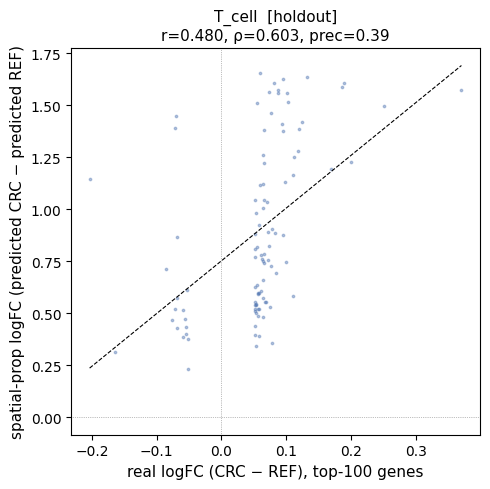

In [16]:
real = stats['real_logfc']
pred = stats['pred_logfc']
mask = stats['top_n_mask']
if mask is not None:
    real, pred = real[mask], pred[mask]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(real, pred, s=3, alpha=0.4, color='#4C72B0')

m, b = np.polyfit(real, pred, 1)
x_lo, x_hi = real.min(), real.max()
ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], 'k--', lw=0.8)
ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.axvline(0, color='grey', lw=0.5, ls=':')

ax.set_xlabel(f'real logFC (CRC − REF), top-{top_n} genes', fontsize=11)
ax.set_ylabel('spatial-prop logFC (predicted CRC − predicted REF)', fontsize=11)
ax.set_title(
    f"{holdout_celltype}  [holdout]\n"
    f"r={stats['pearson_r']:.3f}, ρ={stats['spearman_r']:.3f}, prec={stats['precision']:.2f}",
    fontsize=11,
)

plt.tight_layout()
plt.show()